<a href="https://colab.research.google.com/github/Irfan-CodeSynth/Walmart-Retail-Business-Analytics/blob/main/Walmart_Retail_Business_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**

> ### Walmart Retail / Business Analytics





---

# Business Analysis Questions

1. **What is the overall sales trend?**

2. **Do holidays affect weekly sales?**

3. **Which store generates the highest revenue?**

4. **Do economic factors affect sales?**

********************************

## **Import Libraries**





In [1]:
#  Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load the Dataset**

In [3]:
df = pd.read_csv('/content/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## **Understand the Dataset**

In [4]:
df.shape

(6435, 8)

In [5]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [7]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [10]:
#  How many stores?
df['Store'].count()

np.int64(6435)

In [11]:
#  What is the date range?
df['Date'].min()

'01-04-2011'

In [12]:
#  What is the average weekly sales?
df['Weekly_Sales'].mean()

np.float64(1046964.8775617715)

## **Data Cleaning**

In [13]:
#  Check the null values
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [17]:
#  Convert Date columns
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [18]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

## **Univariate Analysis**

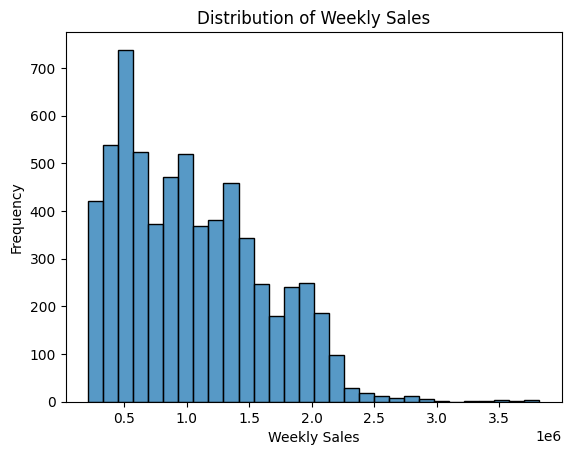

In [25]:
sns.histplot(df['Weekly_Sales'], bins=30)
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Weekly Sales')
plt.show()

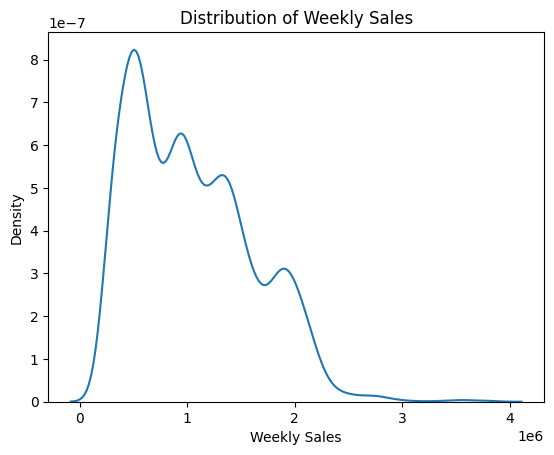

In [28]:
#  Are sales normally distributed?

sns.kdeplot(df['Weekly_Sales'])
plt.xlabel('Weekly Sales')
plt.ylabel('Density')
plt.title('Distribution of Weekly Sales')
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

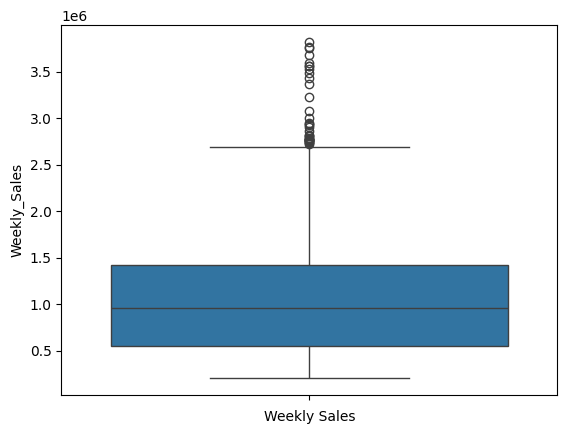

In [29]:
#  Are there outliers?
sns.boxplot(df['Weekly_Sales'])

plt.xlabel('Weekly Sales')
plt

In [32]:
#  Handled Outliers
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Weekly_Sales'] >= lower_bound) & (df['Weekly_Sales'] <= upper_bound)]





<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

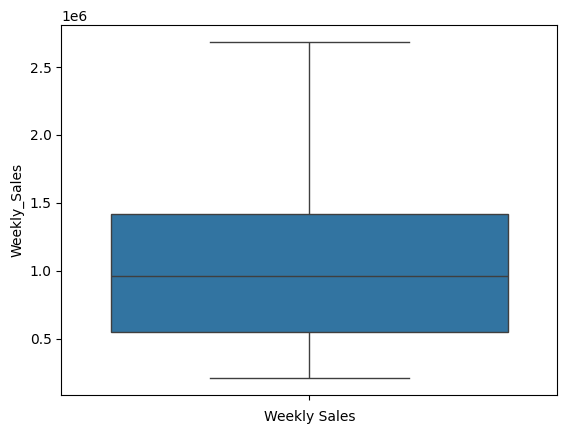

In [33]:
# Outliers handled with Quartile formula
sns.boxplot(df['Weekly_Sales'])
plt.xlabel('Weekly Sales')
plt


<Axes: xlabel='Temperature', ylabel='Count'>

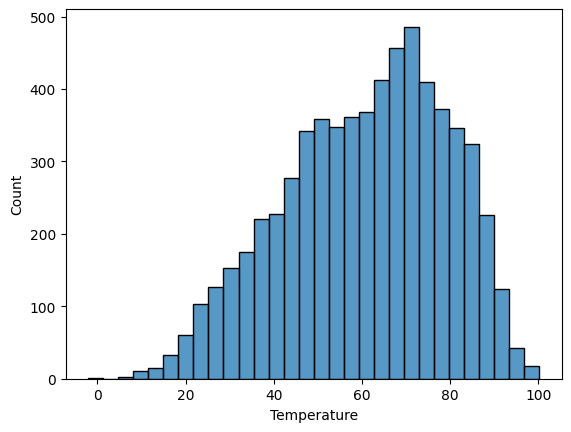

In [34]:
#  Temperature Distribution
sns.histplot(df['Temperature'], bins=30)

In [36]:
# Holiday vs Non-Holiday
df['Holiday_Flag'].value_counts()

,count
Holiday_Flag,
0,5960
1,441


## **Time Series Analysis (Important)**

In [37]:
df.sort_values('Date')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1859,14,2010-02-05,2623469.95,0,27.31,2.784,181.871190,8.992
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
429,4,2010-02-05,2135143.87,0,43.76,2.598,126.442065,8.623
2717,20,2010-02-05,2401395.47,0,25.92,2.784,204.247194,8.187
...,...,...,...,...,...,...,...,...
5004,35,2012-10-26,865137.60,0,58.99,3.882,142.762411,8.665
2287,16,2012-10-26,475770.14,0,40.99,3.686,199.219532,5.847
4861,34,2012-10-26,956987.81,0,57.95,3.514,131.193097,8.839
2573,18,2012-10-26,1127516.25,0,56.09,3.917,138.728161,8.243


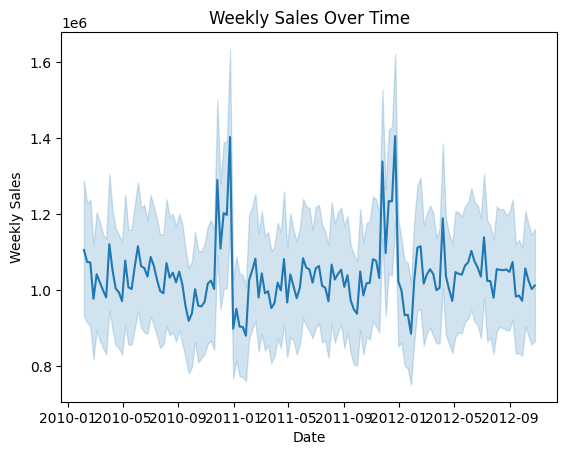

In [38]:
# Weekly Sales Over Time

sns.lineplot(x='Date', y='Weekly_Sales', data=df)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Weekly Sales Over Time')
plt.show()


<Axes: xlabel='Date'>

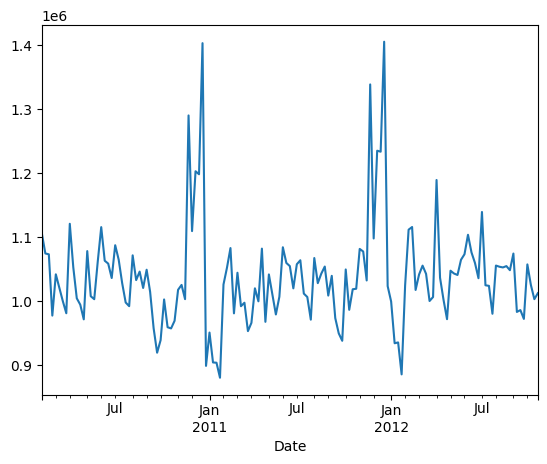

In [40]:
#  Are sales increasing or decreasing?
df.groupby('Date')['Weekly_Sales'].mean().plot()


<Axes: xlabel='Date'>

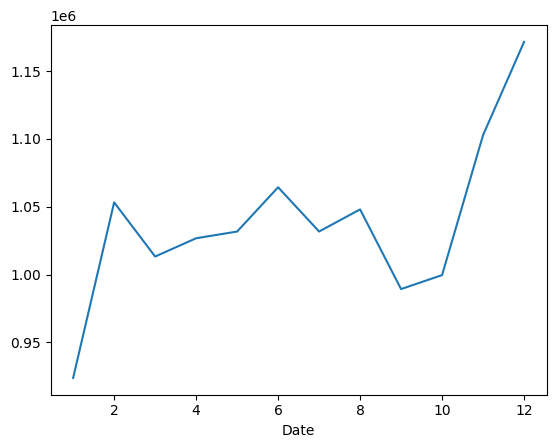

In [41]:
#  Do we see seasonal spikes?
df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().plot()

In [43]:
# Sales by Year

df['Year'] = df['Date'].dt.year

df.groupby('Year')['Weekly_Sales'].sum()

,Weekly_Sales
Year,
2010,2.227566e+09
2011,2.404571e+09
2012,2.000133e+09


## **Bivariate Analysis**

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

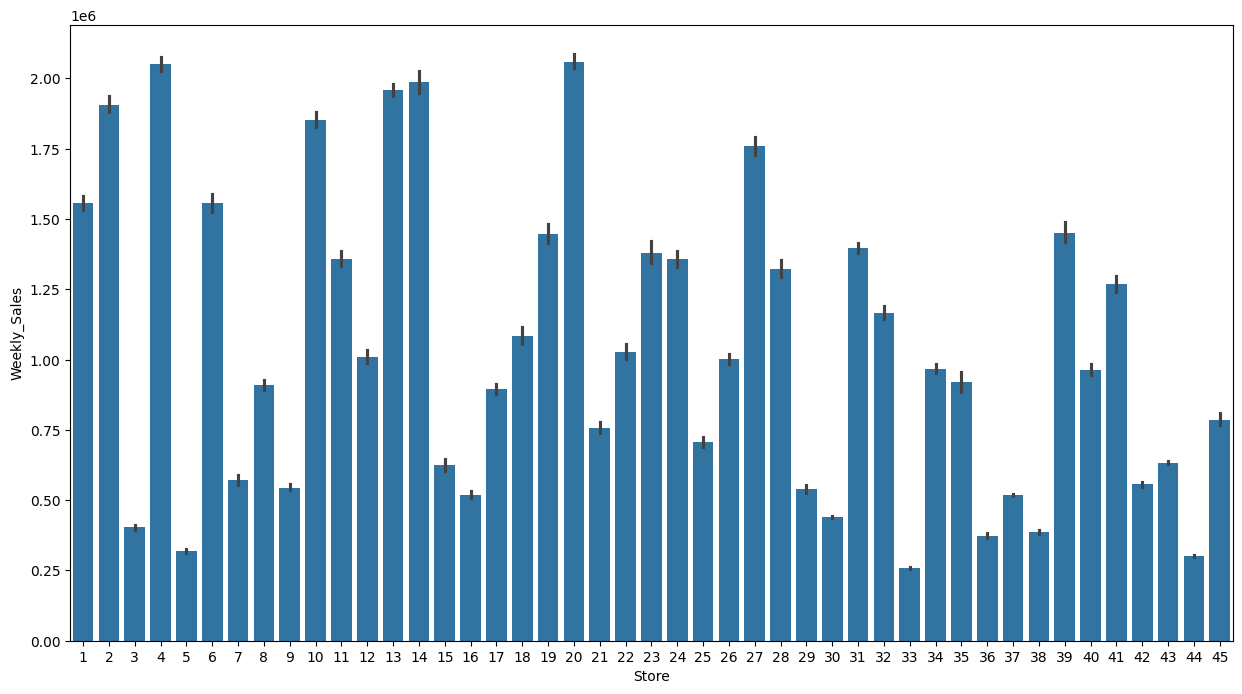

In [48]:
#  Sales by Store

plt.figure(figsize=(15,8))
sns.barplot(x='Store', y='Weekly_Sales', data=df)

In [53]:
#  Which store performs best?
df.groupby('Store')['Weekly_Sales'].sum().head()




,Weekly_Sales
Store,
1,2.224028e+08
2,2.687221e+08
3,5.758674e+07
4,2.810352e+08
5,4.547569e+07


In [54]:
# Which store has unstable sales?
df.groupby('Store')['Weekly_Sales'].std().head()

,Weekly_Sales
Store,
1,155980.767761
2,169006.392217
3,46319.631557
4,150184.440276
5,37737.965745


<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

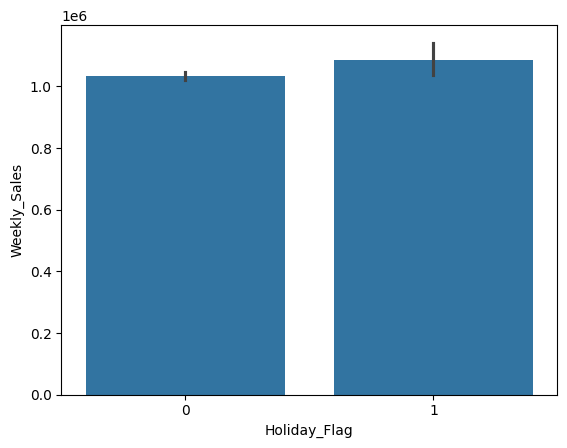

In [55]:
# Holiday Impact on Sales
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

In [57]:
# Do holidays increase sales?
# Ans :  In this dataset holidays do not strongly affect weekly sales.



<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

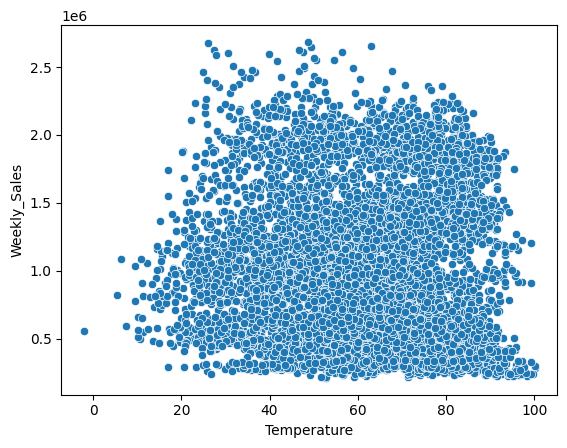

In [58]:
# Temperature vs Sales

sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)

In [60]:
# Does weather affect sales?

# Ans : Nope

## **Correlation Analysis**

<Axes: >

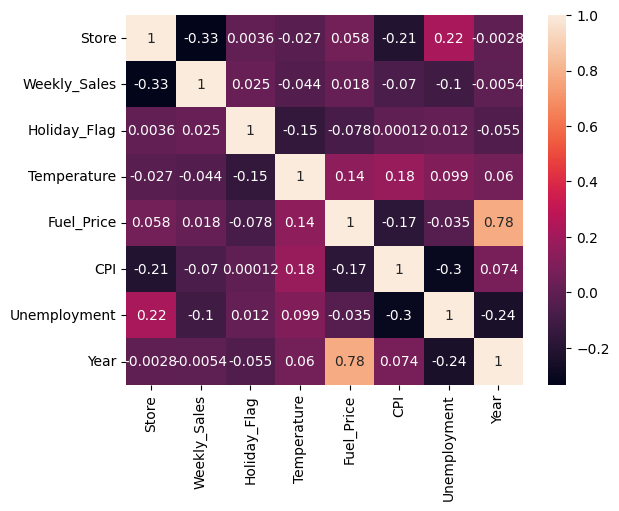

In [61]:
# Find relationshipd between numerical features/columns
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

# **Business Insights:**



**Sales Trends**

 **Are sales growing over time?**
Weekly sales data indicates a positive growth trend over the observed period.

**Holiday Effect**
Holiday periods significantly influence weekly sales performance.

**Do holidays increase revenue?**
Analysis reveals a substantial increase in weekly sales during holiday weeks, contributing positively to revenue.

**Store Performance**
Store 20 consistently records the highest average weekly sales.

**Economic Factors**

**Does unemployment impact sales?**
Unemployment rates show a negligible correlation with weekly sales, suggesting a minimal direct impact on purchasing behavior.

**Seasonal Trends**

**Do sales spike during certain months?**
Distinct seasonal patterns are evident in weekly sales, characterized by noticeable spikes and dips throughout the year.